In [1]:
from structural_geometry_2d import Node, LineMember, Support, StructuralGeometry2D
from structural_geometry_2d.generators import three_hinged_frame

In [2]:
n1 = Node("N1", 0, 0)
n2 = Node("N2", 2, 2)

In [3]:
print(n1.to_dict())
print(n2.to_dict())


{'id': 'N1', 'x': 0.0, 'z': 0.0}
{'id': 'N2', 'x': 2.0, 'z': 2.0}


In [4]:
m1 = LineMember("M1", "N1", "N2", "beam")
print(m1.start_node_id)
print(m1.end_node_id)
print(m1.member_type)
print(m1.id)
print(m1.to_dict)

N1
N2
beam
M1
<bound method LineMember.to_dict of LineMember(id='M1', start_node_id='N1', end_node_id='N2', member_type='beam')>


In [5]:
s1 = Support("S1", "N1", "fixed", "fixed", "fixed")
s1.to_dict()

{'id': 'S1', 'node_id': 'N1', 'ux': 'fixed', 'uz': 'fixed', 'ry': 'fixed'}

In [6]:
sg2d = StructuralGeometry2D()

In [7]:
sg2d.add_node(n1)
sg2d.add_node(n2)
sg2d.add_member(m1)
sg2d.add_support(s1)

In [8]:
sg2d.to_dict()

{'id': 'SG2D',
 'nodes': [{'id': 'N1', 'x': 0.0, 'z': 0.0}, {'id': 'N2', 'x': 2.0, 'z': 2.0}],
 'members': [{'id': 'M1',
   'start_node_id': 'N1',
   'end_node_id': 'N2',
   'type': 'beam'}],
 'supports': [{'id': 'S1',
   'node_id': 'N1',
   'ux': 'fixed',
   'uz': 'fixed',
   'ry': 'fixed'}]}

In [9]:
print(sg2d.validate())

None


In [10]:
model1 = three_hinged_frame.generate_three_hinged_frame(10, 4, 5, "frame_1")

In [11]:
model1.members

[LineMember(id='M1', start_node_id='N1', end_node_id='N2', member_type='column'),
 LineMember(id='M2', start_node_id='N2', end_node_id='N3', member_type='rafter'),
 LineMember(id='M3', start_node_id='N3', end_node_id='N4', member_type='rafter'),
 LineMember(id='M4', start_node_id='N4', end_node_id='N5', member_type='column')]

In [12]:
model1.to_dict()

{'id': 'frame_1',
 'nodes': [{'id': 'N1', 'x': 0.0, 'z': 0.0},
  {'id': 'N2', 'x': 0.0, 'z': 4.0},
  {'id': 'N3', 'x': 5.0, 'z': 5.0},
  {'id': 'N4', 'x': 10.0, 'z': 4.0},
  {'id': 'N5', 'x': 10.0, 'z': 0.0}],
 'members': [{'id': 'M1',
   'start_node_id': 'N1',
   'end_node_id': 'N2',
   'type': 'column'},
  {'id': 'M2', 'start_node_id': 'N2', 'end_node_id': 'N3', 'type': 'rafter'},
  {'id': 'M3', 'start_node_id': 'N3', 'end_node_id': 'N4', 'type': 'rafter'},
  {'id': 'M4', 'start_node_id': 'N4', 'end_node_id': 'N5', 'type': 'column'}],
 'supports': [{'id': 'S1',
   'node_id': 'N1',
   'ux': 'fixed',
   'uz': 'fixed',
   'ry': 'free'},
  {'id': 'S2', 'node_id': 'N5', 'ux': 'free', 'uz': 'fixed', 'ry': 'free'}]}

In [13]:
model1.to_json()

'{\n  "id": "frame_1",\n  "nodes": [\n    {\n      "id": "N1",\n      "x": 0.0,\n      "z": 0.0\n    },\n    {\n      "id": "N2",\n      "x": 0.0,\n      "z": 4.0\n    },\n    {\n      "id": "N3",\n      "x": 5.0,\n      "z": 5.0\n    },\n    {\n      "id": "N4",\n      "x": 10.0,\n      "z": 4.0\n    },\n    {\n      "id": "N5",\n      "x": 10.0,\n      "z": 0.0\n    }\n  ],\n  "members": [\n    {\n      "id": "M1",\n      "start_node_id": "N1",\n      "end_node_id": "N2",\n      "type": "column"\n    },\n    {\n      "id": "M2",\n      "start_node_id": "N2",\n      "end_node_id": "N3",\n      "type": "rafter"\n    },\n    {\n      "id": "M3",\n      "start_node_id": "N3",\n      "end_node_id": "N4",\n      "type": "rafter"\n    },\n    {\n      "id": "M4",\n      "start_node_id": "N4",\n      "end_node_id": "N5",\n      "type": "column"\n    }\n  ],\n  "supports": [\n    {\n      "id": "S1",\n      "node_id": "N1",\n      "ux": "fixed",\n      "uz": "fixed",\n      "ry": "free"\n    

In [14]:
model1.validate()

In [15]:
from structural_geometry_2d import visualization

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

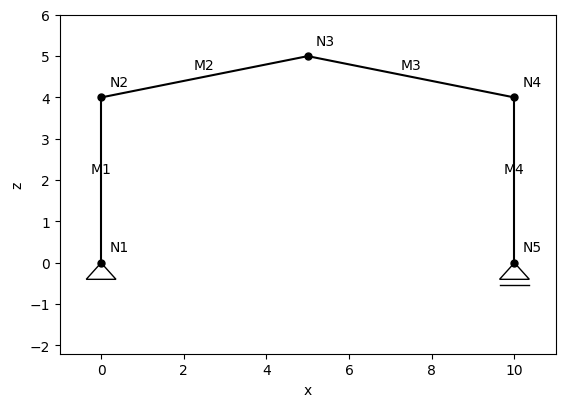

In [16]:
visualization.plot_geometry_2d(model1, show_node_ids=True, show_member_ids=True, show_supports=True)